In [1]:
import pandas as pd

df = pd.read_csv("../dataset/Womens Clothing E-Commerce Reviews.csv")

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [4]:
df = df.dropna(subset=["Review Text"])
df = df.reset_index(drop=True)

df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      2966
Review Text                   0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                13
Department Name              13
Class Name                   13
dtype: int64

In [3]:
df.isnull().sum()


Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [5]:
df["Sentiment"] = df["Rating"].apply(lambda x: "Positive" if x >= 4 else "Negative")

In [6]:
df[["Rating", "Sentiment"]].head()

,Rating,Sentiment
0,4,Positive
1,5,Positive
2,3,Negative
3,5,Positive
4,5,Positive


In [7]:
df["Sentiment"].value_counts()

Sentiment
Positive    17448
Negative     5193
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [9]:
X = df["Review Text"]
y = df["Sentiment"]

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(18112, 13855)
(4529, 13855)


In [11]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [12]:
pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8776771914329874


In [14]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    Negative       0.85      0.58      0.68      1045
    Positive       0.88      0.97      0.92      3484

    accuracy                           0.88      4529
   macro avg       0.86      0.77      0.80      4529
weighted avg       0.87      0.88      0.87      4529



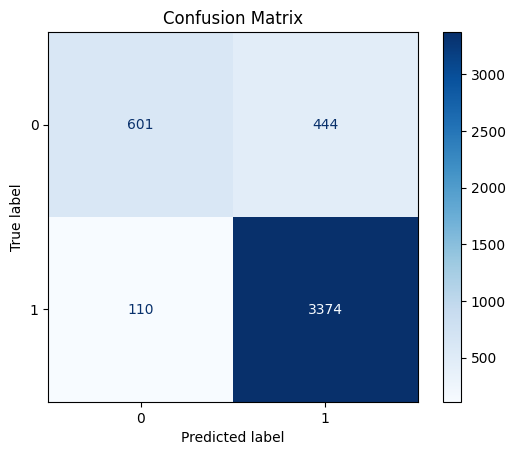

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig("../images/confusion_matrix.png")
plt.show()

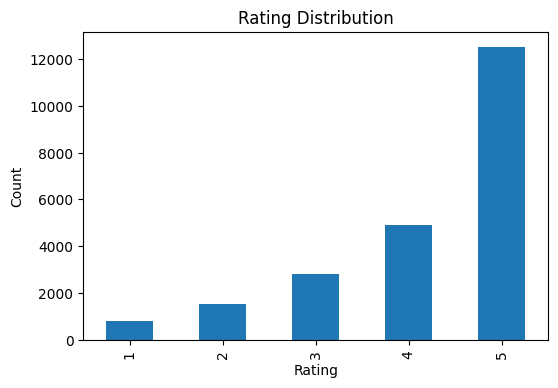

In [16]:
plt.figure(figsize=(6,4))
df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("../images/rating_distribution.png")

plt.show()

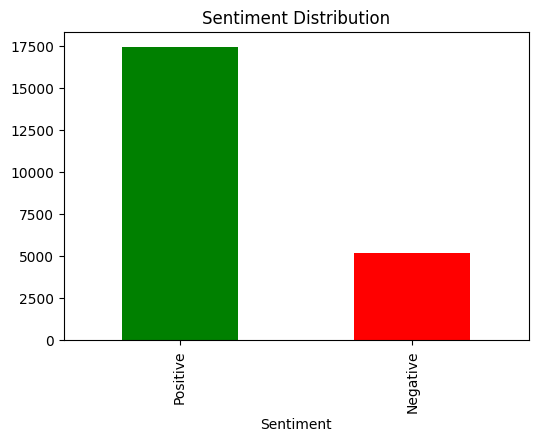

In [17]:
plt.figure(figsize=(6,4))
df["Sentiment"].value_counts().plot(kind="bar", color=["green","red"])

plt.title("Sentiment Distribution")

plt.savefig("../images/sentiment_distribution.png")

plt.show()

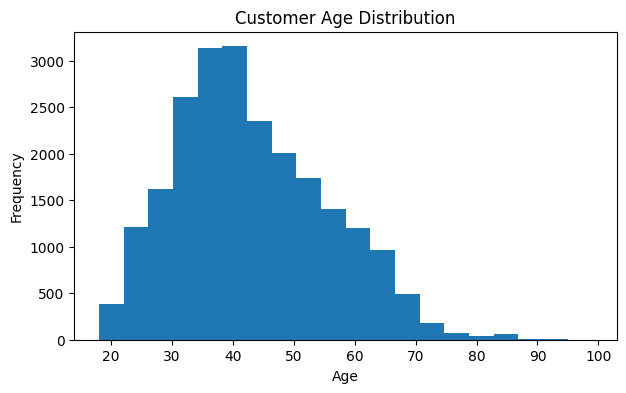

In [18]:
plt.figure(figsize=(7,4))
plt.hist(df["Age"], bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig("../images/age_distribution.png")

plt.show()

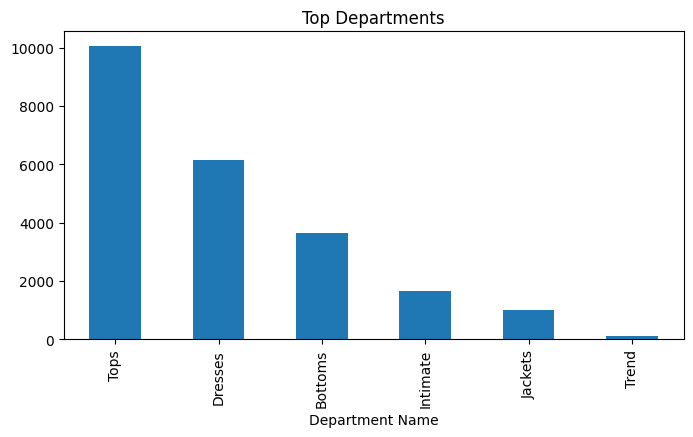

In [19]:
plt.figure(figsize=(8,4))
df["Department Name"].value_counts().head(10).plot(kind="bar")

plt.title("Top Departments")

plt.savefig("../images/top_departments.png")

plt.show()

In [20]:
df.to_csv("../output/cleaned_reviews.csv", index=False)

In [21]:
import joblib

joblib.dump(model, "../output/sentiment_model.pkl")

['../output/sentiment_model.pkl']